<a href="https://colab.research.google.com/github/aditi-g24/forecasting-project/blob/main/training_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##1. Check GPU

In [ ]:
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
if result.returncode == 0:
    print('GPU is available')
    print(result.stdout[:500])
else:
    print('No GPU detected.')

✅ GPU is available!
Thu May  7 10:02:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|       


##2. Install Libraries

In [ ]:
# This cell installs everything needed.
!pip install -q prophet xgboost statsmodels scikit-learn openpyxl
!pip install -q tensorflow==2.15.0
print('All libraries installed')

ERROR: Could not find a version that satisfies the requirement tensorflow==2.15.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)
ERROR: No matching distribution found for tensorflow==2.15.0
✅ All libraries installed!


## 3. Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR   = '/content/drive/MyDrive/forecasting_project'
ARTIFACTS_DIR = f'{PROJECT_DIR}/artifacts'
DATA_DIR      = f'{PROJECT_DIR}/data'

os.makedirs(ARTIFACTS_DIR, exist_ok=True)
os.makedirs(DATA_DIR,      exist_ok=True)
print(f' Google Drive mounted. Project folder: {PROJECT_DIR}')

Mounted at /content/drive
✅ Google Drive mounted. Project folder: /content/drive/MyDrive/forecasting_project


## 4. Upload Dataset

In [ ]:
from google.colab import files
import shutil

print('Please upload your Excel file (sales_data.xlsx / Forecasting_Case-_Study.xlsx)')
uploaded = files.upload()

for fname in uploaded.keys():
    dest = f'{DATA_DIR}/sales_data.xlsx'
    shutil.copy(fname, dest)
    print(f'Uploaded and saved to: {dest}')

Please upload your Excel file (sales_data.xlsx / Forecasting_Case-_Study.xlsx)


Saving Forecasting Case- Study.xlsx to Forecasting Case- Study (1).xlsx
✅ Uploaded and saved to: /content/drive/MyDrive/forecasting_project/data/sales_data.xlsx


## 5. Preprocessing & Feature Engineering

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

# Load data
df = pd.read_excel(f'{DATA_DIR}/sales_data.xlsx')
df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]
df['date'] = pd.to_datetime(df['date'])
if 'total' in df.columns:
    df.rename(columns={'total': 'sales'}, inplace=True)

print(f'Dataset shape: {df.shape}')
print(f'States:        {df["state"].nunique()}')
print(f'Date range:    {df["date"].min().date()} → {df["date"].max().date()}')
print(f'Columns:       {df.columns.tolist()}')
df.head()

Dataset shape: (8084, 4)
States:        43
Date range:    2019-01-12 → 2023-12-03
Columns:       ['state', 'date', 'sales', 'category']


,state,date,sales,category
0,Alabama,2019-01-12,109574036.0,Beverages
1,Arizona,2019-01-12,109101594.6,Beverages
2,Arkansas,2019-01-12,58049432.2,Beverages
3,California,2019-01-12,444766890.6,Beverages
4,Colorado,2019-01-12,89816716.3,Beverages


In [ ]:
# Preprocessing functions

def clean_and_resample(df, state, freq='W'):
    """Filter to one state and resample to a regular weekly series."""
    s = df[df['state'] == state].copy()
    s = s.sort_values('date').drop_duplicates('date')
    s = s.set_index('date')[['sales']]
    weekly = s.resample(freq).sum()
    weekly['sales'] = weekly['sales'].replace(0, np.nan)
    weekly['sales'] = weekly['sales'].interpolate(method='linear').ffill().bfill()
    weekly.reset_index(inplace=True)
    weekly.rename(columns={'date': 'ds', 'sales': 'y'}, inplace=True)
    return weekly


FEATURE_COLS = [
    'lag_1', 'lag_4', 'lag_8', 'lag_13',
    'rolling_mean_4', 'rolling_mean_13', 'rolling_std_4',
    'week_of_year', 'month', 'quarter', 'year', 'trend',
]


def add_features(df):
    """Add lag and calendar features for ML models."""
    df = df.copy().sort_values('ds').reset_index(drop=True)
    y = df['y']
    df['lag_1']  = y.shift(1)
    df['lag_4']  = y.shift(4)
    df['lag_8']  = y.shift(8)
    df['lag_13'] = y.shift(13)
    df['rolling_mean_4']  = y.shift(1).rolling(4).mean()
    df['rolling_mean_13'] = y.shift(1).rolling(13).mean()
    df['rolling_std_4']   = y.shift(1).rolling(4).std()
    df['week_of_year'] = df['ds'].dt.isocalendar().week.astype(int)
    df['month']        = df['ds'].dt.month
    df['quarter']      = df['ds'].dt.quarter
    df['year']         = df['ds'].dt.year
    df['trend']        = np.arange(len(df))
    df.dropna(inplace=True)
    df.reset_index(drop=True, inplace=True)
    return df


def train_test_split_ts(df, test_weeks=8):
    split = len(df) - test_weeks
    return df.iloc[:split].copy(), df.iloc[split:].copy()


def make_future_dates(last_date, weeks=8):
    future_dates = pd.date_range(start=last_date + pd.Timedelta(weeks=1),
                                 periods=weeks, freq='W')
    return pd.DataFrame({'ds': future_dates})


def compute_metrics(actual, predicted):
    from sklearn.metrics import mean_absolute_error, mean_squared_error
    actual    = np.array(actual, dtype=float)
    predicted = np.array(predicted, dtype=float)
    rmse = float(np.sqrt(mean_squared_error(actual, predicted)))
    mae  = float(mean_absolute_error(actual, predicted))
    mask = actual != 0
    mape = float(np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100)
    return {'rmse': round(rmse, 2), 'mae': round(mae, 2), 'mape': round(mape, 4)}


# Quick sanity check on one state
sample = clean_and_resample(df, 'California')
print(f'California weekly series: {len(sample)} observations')
print(sample.tail(3))

California weekly series: 256 observations
            ds             y
253 2023-11-19  1.616375e+09
254 2023-11-26  1.691981e+09
255 2023-12-03  1.767586e+09


## 6. Model Training Functions

We define one function per model. Each returns (metrics_dict, future_forecast_list).

In [ ]:
# SARIMA

def train_sarima(train_df, test_df, forecast_weeks=8):
    from statsmodels.tsa.statespace.sarimax import SARIMAX
    model = SARIMAX(
        train_df['y'].values,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 0, 52),
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    fit = model.fit(disp=False, maxiter=200)
    test_preds   = [max(0, v) for v in fit.forecast(len(test_df))]
    future_preds = [max(0, v) for v in fit.forecast(len(test_df) + forecast_weeks)[-forecast_weeks:]]
    metrics = compute_metrics(test_df['y'].values, test_preds)
    return fit, metrics, future_preds


# Prophet

def train_prophet(train_df, test_df, forecast_weeks=8):
    from prophet import Prophet
    m = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        seasonality_mode='multiplicative',
        changepoint_prior_scale=0.05,
    )
    m.fit(train_df[['ds', 'y']])
    n_total  = len(test_df) + forecast_weeks
    future   = m.make_future_dataframe(periods=n_total, freq='W')
    forecast = m.predict(future)
    test_preds   = [max(0, v) for v in forecast['yhat'].values[-(n_total):-forecast_weeks]]
    future_preds = [max(0, v) for v in forecast['yhat'].values[-forecast_weeks:]]
    metrics = compute_metrics(test_df['y'].values, test_preds)
    return m, metrics, future_preds


# XGBoost

def train_xgboost(train_df, test_df, forecast_weeks=8):
    from xgboost import XGBRegressor
    from sklearn.preprocessing import MinMaxScaler

    scaler = MinMaxScaler()
    df_feat = add_features(train_df)
    X_train = df_feat[FEATURE_COLS].values
    y_train = df_feat['y'].values
    X_scaled = scaler.fit_transform(X_train)

    model = XGBRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
    )
    model.fit(X_scaled, y_train)

    def recursive_forecast(history_df, n):
        history = history_df.copy()
        preds = []
        for _ in range(n):
            feat = add_features(history)
            if len(feat) == 0:
                preds.append(0.0)
                continue
            row  = feat[FEATURE_COLS].iloc[-1].values.reshape(1, -1)
            row_scaled = scaler.transform(row)
            yhat = max(0.0, float(model.predict(row_scaled)[0]))
            preds.append(yhat)
            new_row = pd.DataFrame({'ds': [history['ds'].iloc[-1] + pd.Timedelta(weeks=1)], 'y': [yhat]})
            history = pd.concat([history, new_row], ignore_index=True)
        return preds

    test_preds   = recursive_forecast(train_df, len(test_df))
    full_history = pd.concat([train_df, test_df], ignore_index=True)
    future_preds = recursive_forecast(full_history, forecast_weeks)
    metrics = compute_metrics(test_df['y'].values, test_preds)
    return (model, scaler), metrics, future_preds


# LSTM

LOOK_BACK = 13

def train_lstm(train_df, test_df, forecast_weeks=8, epochs=60):
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping
    from sklearn.preprocessing import MinMaxScaler

    scaler = MinMaxScaler(feature_range=(0, 1))
    values = train_df['y'].values.reshape(-1, 1)
    scaled = scaler.fit_transform(values)

    def make_sequences(data, look_back):
        X, y = [], []
        for i in range(look_back, len(data)):
            X.append(data[i-look_back:i, 0])
            y.append(data[i, 0])
        return np.array(X), np.array(y)

    X_tr, y_tr = make_sequences(scaled, LOOK_BACK)
    X_tr = X_tr.reshape(X_tr.shape[0], X_tr.shape[1], 1)

    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(LOOK_BACK, 1)),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1),
    ])
    model.compile(optimizer='adam', loss='mse')
    es = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)
    model.fit(X_tr, y_tr, epochs=epochs, batch_size=16, callbacks=[es], verbose=0)

    def predict_n(seed_seq, n):
        seq   = seed_seq.copy()
        preds = []
        for _ in range(n):
            X    = seq.reshape(1, LOOK_BACK, 1)
            yhat = float(model.predict(X, verbose=0)[0, 0])
            preds.append(yhat)
            seq  = np.append(seq[1:], [[yhat]], axis=0)
        inv = scaler.inverse_transform(np.array(preds).reshape(-1, 1)).flatten()
        return [max(0.0, float(v)) for v in inv]

    last_seq_train  = scaled[-LOOK_BACK:]
    test_seq_start  = scaled[-(LOOK_BACK + len(test_df)):-len(test_df)]
    test_preds      = predict_n(test_seq_start, len(test_df))

    full_vals = np.concatenate([values, test_df['y'].values.reshape(-1,1)])
    full_scl  = scaler.transform(full_vals)
    future_preds = predict_n(full_scl[-LOOK_BACK:], forecast_weeks)

    metrics = compute_metrics(test_df['y'].values, test_preds)
    return (model, scaler), metrics, future_preds


print(' Model functions defined.')

✅ Model functions defined.


##7. Train All Models for All States


In [ ]:
import joblib, json, time, os

# Config
FORECAST_WEEKS  = 8
TEST_WEEKS      = 8
TRAIN_LSTM      = True   # Set False to skip LSTM

ALL_STATES = sorted(df['state'].unique())
STATES_TO_TRAIN = ALL_STATES  # Change to a small list to test

print(f'Training on {len(STATES_TO_TRAIN)} states …')
print(f'Models: SARIMA + Prophet + XGBoost' + (' + LSTM' if TRAIN_LSTM else ''))

all_results = {}
t_total = time.time()

for state in STATES_TO_TRAIN:
    print(f'\n── {state} ──')
    state_key = state.replace(' ', '_')
    state_dir = f'{ARTIFACTS_DIR}/{state_key}'
    os.makedirs(state_dir, exist_ok=True)

    weekly   = clean_and_resample(df, state)
    train_df, test_df = train_test_split_ts(weekly, TEST_WEEKS)

    state_metrics   = {}
    state_forecasts = {}

    # SARIMA
    try:
        t0 = time.time()
        obj, m, fc = train_sarima(train_df, test_df, FORECAST_WEEKS)
        joblib.dump(obj, f'{state_dir}/sarima.pkl')
        state_metrics['sarima']   = m
        state_forecasts['sarima'] = fc
        print(f'  SARIMA  RMSE={m["rmse"]:>12,.0f}  MAE={m["mae"]:>12,.0f}  MAPE={m["mape"]:>6.2f}%  ({time.time()-t0:.1f}s)')
    except Exception as e:
        print(f'  SARIMA  FAILED: {e}')

    # Prophet
    try:
        t0 = time.time()
        obj, m, fc = train_prophet(train_df, test_df, FORECAST_WEEKS)
        joblib.dump(obj, f'{state_dir}/prophet.pkl')
        state_metrics['prophet']   = m
        state_forecasts['prophet'] = fc
        print(f'  Prophet RMSE={m["rmse"]:>12,.0f}  MAE={m["mae"]:>12,.0f}  MAPE={m["mape"]:>6.2f}%  ({time.time()-t0:.1f}s)')
    except Exception as e:
        print(f'  Prophet FAILED: {e}')

    # XGBoost
    try:
        t0 = time.time()
        obj, m, fc = train_xgboost(train_df, test_df, FORECAST_WEEKS)
        joblib.dump(obj, f'{state_dir}/xgboost.pkl')
        state_metrics['xgboost']   = m
        state_forecasts['xgboost'] = fc
        print(f'  XGBoost RMSE={m["rmse"]:>12,.0f}  MAE={m["mae"]:>12,.0f}  MAPE={m["mape"]:>6.2f}%  ({time.time()-t0:.1f}s)')
    except Exception as e:
        print(f'  XGBoost FAILED: {e}')

    # LSTM
    if TRAIN_LSTM:
        try:
            t0 = time.time()
            obj, m, fc = train_lstm(train_df, test_df, FORECAST_WEEKS)
            model_obj, scaler_obj = obj
            model_obj.save(f'{state_dir}/lstm_model.h5')
            joblib.dump(scaler_obj, f'{state_dir}/lstm_scaler.pkl')
            state_metrics['lstm']   = m
            state_forecasts['lstm'] = fc
            print(f'  LSTM    RMSE={m["rmse"]:>12,.0f}  MAE={m["mae"]:>12,.0f}  MAPE={m["mape"]:>6.2f}%  ({time.time()-t0:.1f}s)')
        except Exception as e:
            print(f'  LSTM    FAILED: {e}')

    # Best model selection
    if not state_metrics:
        print(f'    All models failed for {state}. Skipping.')
        continue

    best_model = min(state_metrics, key=lambda k: state_metrics[k]['rmse'])
    best_fc    = state_forecasts[best_model]
    print(f'  ★ Best: {best_model.upper()} (RMSE={state_metrics[best_model]["rmse"]:,.0f})')

    last_date    = weekly['ds'].max()
    future_dates = make_future_dates(last_date, FORECAST_WEEKS)

    forecast_records = [
        {'date': str(d.date()), 'sales': round(v, 2)}
        for d, v in zip(future_dates['ds'], best_fc)
    ]

    summary = {
        'state':      state,
        'best_model': best_model,
        'metrics':    state_metrics,
        'forecast':   forecast_records,
    }

    with open(f'{state_dir}/summary.json', 'w') as f:
        json.dump(summary, f, indent=2)

    all_results[state] = summary

with open(f'{ARTIFACTS_DIR}/all_results.json', 'w') as f:
    json.dump(all_results, f, indent=2)

print(f'\n\n Training complete! Total time: {(time.time()-t_total)/60:.1f} minutes')
print(f'Results saved to: {ARTIFACTS_DIR}/all_results.json')

Training on 43 states …
Models: SARIMA + Prophet + XGBoost + LSTM

── Alabama ──
  SARIMA  RMSE= 100,423,734  MAE=  87,399,834  MAPE= 24.29%  (11.6s)
  Prophet RMSE=  78,619,359  MAE=  58,679,329  MAPE= 15.95%  (2.3s)
  XGBoost RMSE=  84,721,262  MAE=  67,951,006  MAPE= 18.23%  (1.2s)


  LSTM    RMSE= 154,680,801  MAE= 147,799,089  MAPE= 41.26%  (19.3s)
  ★ Best: PROPHET (RMSE=78,619,359)

── Arizona ──
  SARIMA  RMSE= 108,879,983  MAE=  95,606,329  MAPE= 24.38%  (8.4s)
  Prophet RMSE=  92,649,708  MAE=  74,215,201  MAPE= 18.68%  (0.7s)
  XGBoost RMSE= 108,790,803  MAE=  88,375,828  MAPE= 21.62%  (2.6s)


  LSTM    RMSE= 157,606,671  MAE= 154,547,449  MAPE= 39.91%  (14.9s)
  ★ Best: PROPHET (RMSE=92,649,708)

── Arkansas ──
  SARIMA  RMSE=  53,452,049  MAE=  47,812,716  MAPE= 24.85%  (8.2s)
  Prophet RMSE=  43,035,714  MAE=  33,377,943  MAPE= 17.05%  (0.2s)
  XGBoost RMSE=  50,913,580  MAE=  42,469,616  MAPE= 21.31%  (0.5s)


  LSTM    RMSE=  89,209,484  MAE=  87,398,958  MAPE= 45.93%  (12.1s)
  ★ Best: PROPHET (RMSE=43,035,714)

── California ──
  SARIMA  RMSE= 454,466,273  MAE= 393,419,003  MAPE= 25.50%  (11.7s)
  Prophet RMSE= 371,587,647  MAE= 294,152,602  MAPE= 18.75%  (0.9s)
  XGBoost RMSE= 413,550,623  MAE= 360,331,263  MAPE= 22.74%  (0.5s)


  LSTM    RMSE= 555,039,222  MAE= 540,277,624  MAPE= 35.45%  (15.6s)
  ★ Best: PROPHET (RMSE=371,587,647)

── Colorado ──
  SARIMA  RMSE=  90,432,478  MAE=  79,702,941  MAPE= 25.73%  (11.2s)
  Prophet RMSE=  72,974,253  MAE=  57,482,781  MAPE= 18.28%  (0.9s)
  XGBoost RMSE=  89,944,674  MAE=  78,483,954  MAPE= 24.69%  (0.5s)


...

  LSTM    RMSE= 225,966,415  MAE= 217,894,436  MAPE= 43.18%  (13.8s)
  ★ Best: PROPHET (RMSE=116,577,914)

── Washington ──
  SARIMA  RMSE=  91,754,883  MAE=  81,960,786  MAPE= 25.23%  (27.3s)
  Prophet RMSE=  74,358,202  MAE=  59,534,859  MAPE= 18.07%  (0.3s)
  XGBoost RMSE=  82,110,528  MAE=  67,579,614  MAPE= 20.01%  (1.0s)


  LSTM    RMSE= 128,815,719  MAE= 124,256,739  MAPE= 38.30%  (30.0s)
  ★ Best: PROPHET (RMSE=74,358,202)

── West Virginia ──
  SARIMA  RMSE=  37,789,129  MAE=  33,969,672  MAPE= 25.83%  (35.4s)
  Prophet RMSE=  31,416,062  MAE=  25,413,337  MAPE= 19.08%  (0.6s)
  XGBoost RMSE=  38,276,017  MAE=  31,705,192  MAPE= 23.13%  (0.6s)


  LSTM    RMSE=  56,387,809  MAE=  54,445,719  MAPE= 41.47%  (13.7s)
  ★ Best: PROPHET (RMSE=31,416,062)

── Wisconsin ──
  SARIMA  RMSE=  76,367,259  MAE=  68,390,721  MAPE= 25.08%  (13.7s)
  Prophet RMSE=  60,138,152  MAE=  47,469,396  MAPE= 17.15%  (0.4s)
  XGBoost RMSE=  65,116,324  MAE=  52,672,488  MAPE= 18.46%  (0.7s)


  LSTM    RMSE= 102,100,058  MAE= 101,075,610  MAPE= 37.68%  (20.2s)
  ★ Best: PROPHET (RMSE=60,138,152)

── Wyoming ──
  SARIMA  RMSE=  11,120,555  MAE=   9,868,165  MAPE= 26.69%  (16.9s)
  Prophet RMSE=   8,378,729  MAE=   6,614,602  MAPE= 17.50%  (0.5s)
  XGBoost RMSE=   6,827,273  MAE=   6,016,761  MAPE= 15.86%  (4.0s)


  LSTM    RMSE=  14,375,893  MAE=  13,739,105  MAPE= 37.04%  (11.9s)
  ★ Best: XGBOOST (RMSE=6,827,273)


✅ Training complete! Total time: 26.7 minutes
Results saved to: /content/drive/MyDrive/forecasting_project/artifacts/all_results.json


## 8. Visualise Results

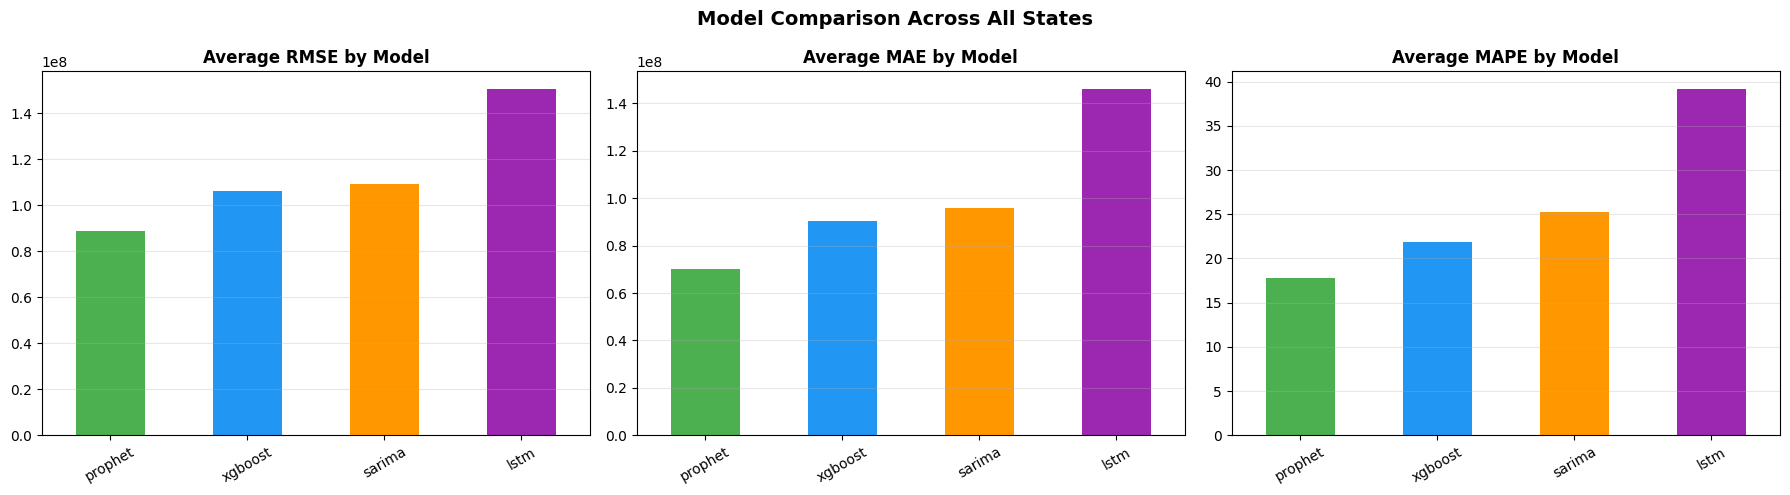

In [ ]:
# Model comparison across all states

records = []
for state, data in all_results.items():
    for model, m in data['metrics'].items():
        records.append({'state': state, 'model': model, **m})
metrics_df = pd.DataFrame(records)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric in zip(axes, ['rmse', 'mae', 'mape']):
    pivot = metrics_df.pivot_table(index='state', columns='model', values=metric)
    pivot.mean().sort_values().plot(kind='bar', ax=ax, color=['#4CAF50','#2196F3','#FF9800','#9C27B0'][:len(pivot.columns)])
    ax.set_title(f'Average {metric.upper()} by Model', fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Model Comparison Across All States', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{ARTIFACTS_DIR}/model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

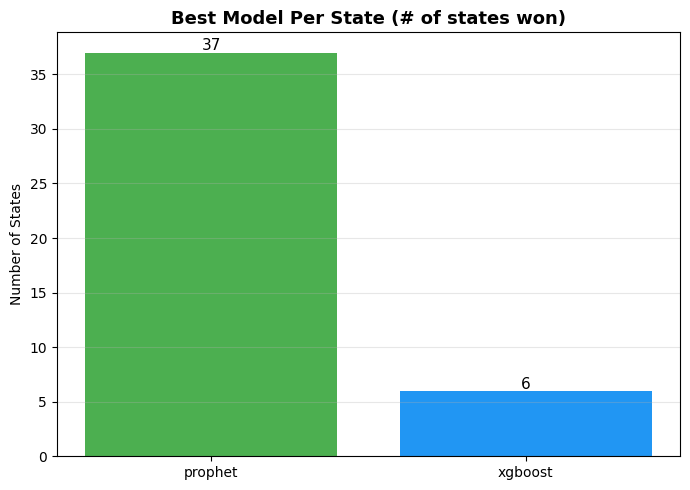

Model wins: {'prophet': 37, 'xgboost': 6}


In [ ]:
# Best model wins
best_counts = {}
for data in all_results.values():
    bm = data['best_model']
    best_counts[bm] = best_counts.get(bm, 0) + 1

plt.figure(figsize=(7, 5))
plt.bar(best_counts.keys(), best_counts.values(),
        color=['#4CAF50','#2196F3','#FF9800','#9C27B0'][:len(best_counts)])
plt.title('Best Model Per State (# of states won)', fontsize=13, fontweight='bold')
plt.ylabel('Number of States')
plt.grid(axis='y', alpha=0.3)
for i, (k, v) in enumerate(best_counts.items()):
    plt.text(i, v + 0.2, str(v), ha='center', fontsize=11)
plt.tight_layout()
plt.savefig(f'{ARTIFACTS_DIR}/best_model_wins.png', dpi=120)
plt.show()

print('Model wins:', best_counts)

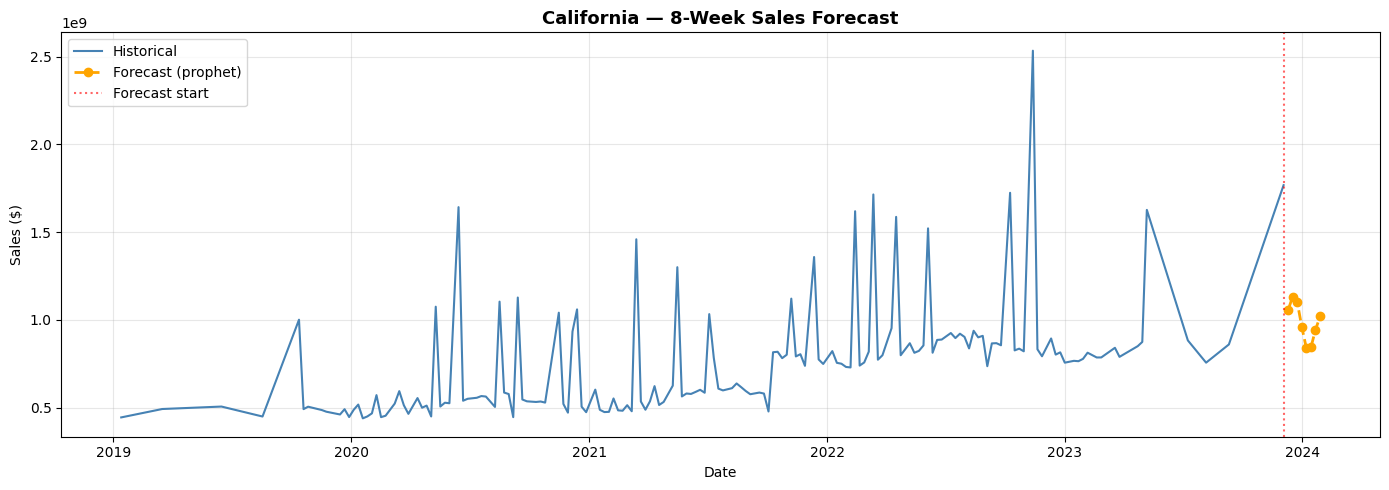

In [ ]:
# Forecast plot for one state
EXAMPLE_STATE = 'California'  # Change to any state in your dataset

weekly_ex  = clean_and_resample(df, EXAMPLE_STATE)
result_ex  = all_results[EXAMPLE_STATE]
forecast_records = result_ex['forecast']

fc_df = pd.DataFrame(forecast_records)
fc_df['date'] = pd.to_datetime(fc_df['date'])

plt.figure(figsize=(14, 5))
plt.plot(weekly_ex['ds'], weekly_ex['y'], label='Historical', color='steelblue', linewidth=1.5)
plt.plot(fc_df['date'], fc_df['sales'], label=f'Forecast ({result_ex["best_model"]})',
         color='orange', linewidth=2, linestyle='--', marker='o', markersize=6)
plt.axvline(weekly_ex['ds'].max(), color='red', linestyle=':', alpha=0.6, label='Forecast start')
plt.title(f'{EXAMPLE_STATE} — 8-Week Sales Forecast', fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{ARTIFACTS_DIR}/{EXAMPLE_STATE.replace(" ","_")}_forecast.png', dpi=120)
plt.show()

## 9. Summary Table

In [ ]:
rows = []
for state, data in all_results.items():
    bm = data['best_model']
    m  = data['metrics'][bm]
    rows.append({'State': state, 'Best Model': bm.upper(),
                 'RMSE': f"{m['rmse']:,.0f}", 'MAE': f"{m['mae']:,.0f}",
                 'MAPE (%)': f"{m['mape']:.2f}"})

summary_table = pd.DataFrame(rows).sort_values('State')
print(summary_table.to_string(index=False))

         State Best Model        RMSE         MAE MAPE (%)
       Alabama    PROPHET  78,619,359  58,679,329    15.95
       Arizona    PROPHET  92,649,708  74,215,201    18.68
      Arkansas    PROPHET  43,035,714  33,377,943    17.05
    California    PROPHET 371,587,647 294,152,602    18.75
      Colorado    PROPHET  72,974,253  57,482,781    18.28
   Connecticut    PROPHET  34,684,534  28,329,478    18.02
       Florida    PROPHET 344,377,200 278,627,121    20.50
       Georgia    PROPHET 147,442,867 111,653,758    16.41
      Illinois    PROPHET 137,173,869 112,180,252    19.57
       Indiana    PROPHET  87,220,513  68,112,149    17.29
          Iowa    XGBOOST  41,155,342  32,104,736    15.33
        Kansas    PROPHET  34,781,295  27,671,700    17.39
      Kentucky    PROPHET  66,547,640  51,944,613    16.99
     Louisiana    PROPHET  76,794,485  60,726,982    18.47
         Maine    XGBOOST  14,419,076  12,571,931    14.94
      Maryland    PROPHET  63,949,425  50,569,778    17.

##10. Download Artifacts



In [ ]:
import shutil
from google.colab import files

zip_path = '/content/artifacts_export'
shutil.make_archive(zip_path, 'zip', ARTIFACTS_DIR)
print(f' Zipped: {zip_path}.zip')
files.download(f'{zip_path}.zip')
print(' Download started!')

✅ Zipped: /content/artifacts_export.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  Download started!
